## Análise Exploratória dos Dados (EDA)
Notebook para validar as transformações, features e flags criadas na pipeline em src/pyspark e explorar os dados com base no Sample de Janeiro e Fevereiro de 2026.

#### Análise da qualidade dos dados após tratamentos e criação de features
- Validação de colunas
- Validação de features
- Validação de nulls

### EDA



In [1]:
from pathlib import Path
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

In [2]:
## Imports
from pyspark.sql.functions import col, trim, lower
from src.pyspark.extract import extract_veiculos
from src.pyspark.transform import transform_veiculos ### Importa as funções criadas ao decorrer do texto
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
### Ler um dos arquivos e validar schema inicial
file_path = "../data/criminalidade/raw/VeiculosSubtraidos_2026.xlsx"

df_raw = extract_veiculos(file_path, 2026)

df = transform_veiculos(df_raw)
df.printSchema()
df.show(n=10, truncate=False, vertical=False)

root
 |-- id_delegacia: integer (nullable = true)
 |-- nome_seccional: string (nullable = true)
 |-- nome_delegacia: string (nullable = true)
 |-- nome_municipio: string (nullable = true)
 |-- ano_bo: integer (nullable = true)
 |-- num_bo: string (nullable = true)
 |-- versao: integer (nullable = true)
 |-- nome_departamento_circ: string (nullable = true)
 |-- nome_seccional_circ: string (nullable = true)
 |-- nome_delegacia_circ: string (nullable = true)
 |-- nome_municipio_circ: string (nullable = true)
 |-- data_ocorrencia_bo: date (nullable = true)
 |-- hora_ocorrencia: string (nullable = true)
 |-- datahora_registro_bo: timestamp (nullable = true)
 |-- data_comunicacao_bo: date (nullable = true)
 |-- datahora_impressao_bo: timestamp (nullable = true)
 |-- autoria_bo: string (nullable = true)
 |-- flag_flagrante: string (nullable = true)
 |-- flag_status: string (nullable = true)
 |-- rubrica: string (nullable = true)
 |-- descr_conduta: string (nullable = true)
 |-- descr_tipoloca

In [ ]:
print(df.count())
print(df.dropDuplicates().count())

33132
30519


### Remoção de Registros Duplicados

Durante a etapa de análise exploratória e validação dos dados, foram identificados registros completamente duplicados no dataset, incluindo ocorrências com mesmas informações de rubrica, timestamps, localização e demais atributos.

Esses registros foram removidos utilizando `dropDuplicates()`, preservando apenas ocorrências únicas.

Segundo a própria Secretaria de Segurança Pública do Estado de São Paulo (SSP-SP), os dados disponibilizados possuem caráter bruto, não passando necessariamente por processos prévios de limpeza, tratamento ou padronização, podendo conter inconsistências, duplicidades e problemas de preenchimento.

Dessa forma, a remoção de duplicidades foi necessária para aumentar a consistência e confiabilidade das análises estatísticas e geoespaciais realizadas no projeto.

- `Remoção de duplicidade adicionada ao Dataset no final da pipeline`

In [4]:
print(df.count())
print(df.dropDuplicates().count())

30519
30519


In [5]:
columns_to_analyze = [
    "categoria_rubrica",
    "categoria_ocorrencia_veiculo",
    "categoria_tipo_veiculo",
    "categoria_tipolocal",
    "categoria_conduta",
    "periodo_dia",
    "bairro"
]

for column_name in columns_to_analyze:
    print(f"\n### {column_name} ###")
    (
        df.groupBy(column_name)
        .count()
        .orderBy(col("count").desc())
        .show(25, truncate=False)
    )


### categoria_rubrica ###
+-----------------+-----+
|categoria_rubrica|count|
+-----------------+-----+
|FURTO            |13801|
|RECUPERACAO      |10097|
|ROUBO            |3760 |
|OUTROS           |1116 |
|RECEPTACAO       |675  |
|ADULTERACAO      |494  |
|FRAUDE           |202  |
|VIOLENCIA        |169  |
|DROGAS           |80   |
|ARMAS            |71   |
|ACIDENTE         |54   |
+-----------------+-----+


### categoria_ocorrencia_veiculo ###
+----------------------------+-----+
|categoria_ocorrencia_veiculo|count|
+----------------------------+-----+
|RECUPERADO                  |16927|
|FURTADO                     |11177|
|ROUBADO                     |2415 |
+----------------------------+-----+


### categoria_tipo_veiculo ###
+----------------------+-----+
|categoria_tipo_veiculo|count|
+----------------------+-----+
|LEVE                  |17684|
|MOTOCICLETA           |11065|
|PESADO                |1484 |
|OUTROS                |110  |
|TRANSPORTE_PUBLICO    |88   |
|MAQ

#### Qualidade
A qualidade das principais features parece boa. Poucos ou nenhum nullos e aparentam consistência suficiente para análises

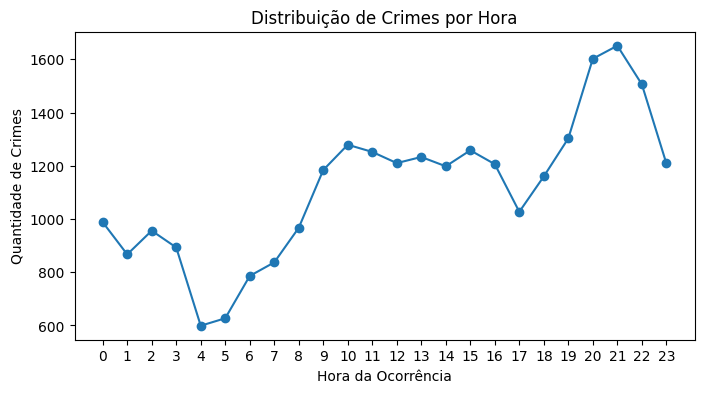

In [17]:
# df.groupBy("hora_ocorrencia_num")\
#     .count()\
#     .orderBy("hora_ocorrencia_num")\
#     .show(25)

hour_df = (
    df.groupBy("hora_ocorrencia_num")
    .count()
    .orderBy("hora_ocorrencia_num")
    .toPandas()
)

hour_df = hour_df.dropna()

plt.figure(figsize=(8, 4))

plt.plot(
    hour_df["hora_ocorrencia_num"],
    hour_df["count"],
    marker="o"
)

plt.xticks(range(0, 24))
plt.xlabel("Hora da Ocorrência")
plt.ylabel("Quantidade de Crimes")
plt.title("Distribuição de Crimes por Hora")

plt.show()

#### Horários
A maior parte das ocorrências parece ocorrer no período noturno. Principalmente entre 20:00 e 22:00h.
O horário mais seguro no sample parece ser as 04:00am, deve correlacionar com o fator de menos carros na rua.
No entando, é notório como 20-22:00pm já é pós horário de pico 16:00-20:00pm

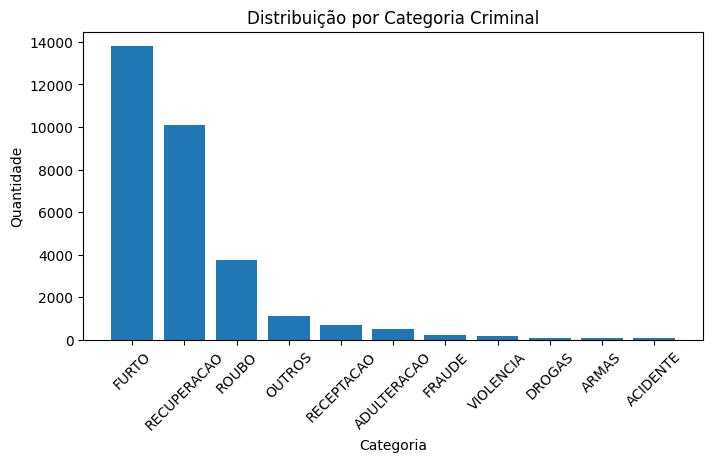

In [14]:
# df.groupBy("categoria_tipo_veiculo", "categoria_rubrica")\
#     .count()\
#     .orderBy(col("count").desc())\
#     .show(50, truncate=False)

crime_df = (
    df.groupBy("categoria_rubrica")
    .count()
    .orderBy(col("count").desc())
    .toPandas()
)

plt.figure(figsize=(8, 4))

plt.bar(
    crime_df["categoria_rubrica"],
    crime_df["count"]
)

plt.xlabel("Categoria")
plt.ylabel("Quantidade")
plt.title("Distribuição por Categoria Criminal")

plt.xticks(rotation=45)

plt.show()

#### Rúbrica
As ocorrências se concentram principalmente em Furtos, Roubos e Recuperação de veículos. 
É notório o fator de que existe um número consideravelmente maior de Furtos do que Roubos

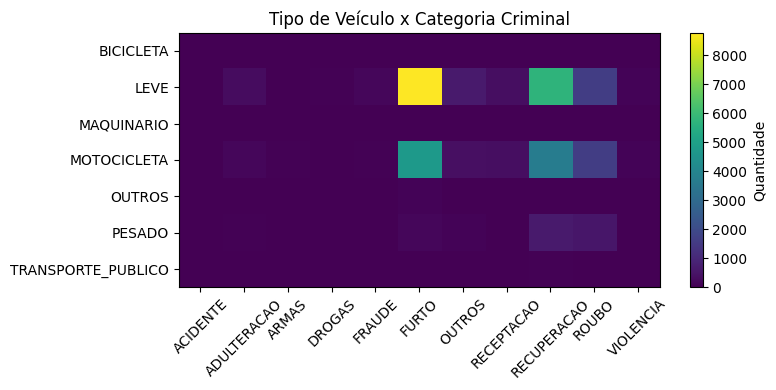

In [ ]:
vehicle_df = (
    df.groupBy(
        "categoria_tipo_veiculo",
        "categoria_rubrica"
    )
    .count()
    .toPandas()
)

pivot_df = vehicle_df.pivot(
    index="categoria_tipo_veiculo",
    columns="categoria_rubrica",
    values="count"
).fillna(0)

plt.figure(figsize=(8, 4))

plt.imshow(pivot_df, aspect="auto")

plt.colorbar(label="Quantidade")

plt.xticks(
    range(len(pivot_df.columns)),
    pivot_df.columns,
    rotation=45
)

plt.yticks(
    range(len(pivot_df.index)),
    pivot_df.index
)

plt.title("Tipo de Veículo x Categoria Criminal")

plt.tight_layout()

plt.show()

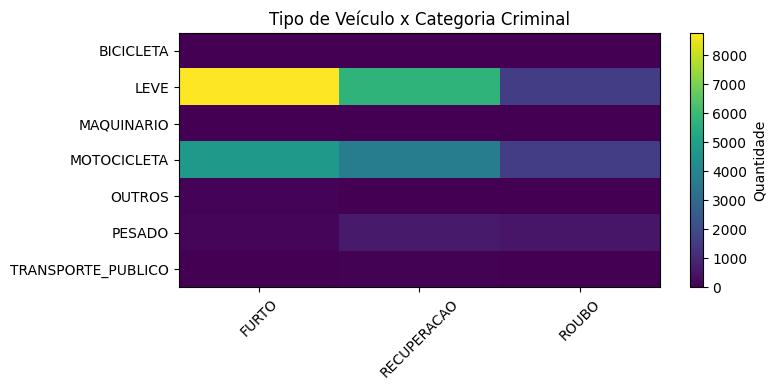

In [ ]:
vehicle_df = (
    df.filter(
        col("categoria_rubrica").isin(
            "FURTO",
            "ROUBO",
            "RECUPERACAO"
        )
    )
    .groupBy(
        "categoria_tipo_veiculo",
        "categoria_rubrica"
    )
    .count()
    .toPandas()
)

pivot_df = vehicle_df.pivot(
    index="categoria_tipo_veiculo",
    columns="categoria_rubrica",
    values="count"
).fillna(0)

plt.figure(figsize=(8, 4))

plt.imshow(pivot_df, aspect="auto")

plt.colorbar(label="Quantidade")

plt.xticks(
    range(len(pivot_df.columns)),
    pivot_df.columns,
    rotation=45
)

plt.yticks(
    range(len(pivot_df.index)),
    pivot_df.index
)

plt.title("Tipo de Veículo x Categoria Criminal")

plt.tight_layout()

plt.show()

#### Tipo de Veículo e Ocorrência
Tem bastante barulho entre as categorias com muitas apresentadno valores muito baixos de ocorrências.
Considerando somente Furto, Recuperação e Roubo há uma clara concentração em veículos leves, condizente com a frota de veículos de São Paulo.
No entanto, motocicletas parecem desproporcionalmente mais impactadas pela criminalidade

In [7]:
(
    df
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv("../data/criminalidade/processed/veiculos_2026_tratado_sample.csv")
)

#### Salvar sample
Salvar o sample da análise inicial para validar as coordenadas no QGIs.
- Passou no teste, coordenadas validadas. Somente os 4,5% com valores nullos não foram representados. Provavelmente removeremos esses registros da análise final

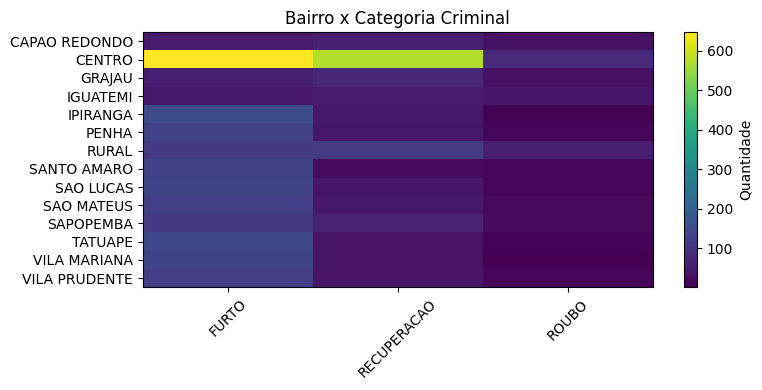

In [9]:
top_bairros = (
    df.groupBy("bairro")
    .count()
    .orderBy(col("count").desc())
    .limit(15)
    .select("bairro")
    .rdd.flatMap(lambda x: x)
    .collect()
)

bairro_df = (
    df.filter(
        (col("bairro").isin(top_bairros)) &
        (col("categoria_rubrica").isin(
            "FURTO",
            "ROUBO",
            "RECUPERACAO"
        ))
    )
    .groupBy(
        "bairro",
        "categoria_rubrica"
    )
    .count()
    .toPandas()
)

pivot_df = bairro_df.pivot(
    index="bairro",
    columns="categoria_rubrica",
    values="count"
).fillna(0)

plt.figure(figsize=(8, 4))

plt.imshow(pivot_df, aspect="auto")

plt.colorbar(label="Quantidade")

plt.xticks(
    range(len(pivot_df.columns)),
    pivot_df.columns,
    rotation=45
)

plt.yticks(
    range(len(pivot_df.index)),
    pivot_df.index
)

plt.title("Bairro x Categoria Criminal")

plt.tight_layout()

plt.show()

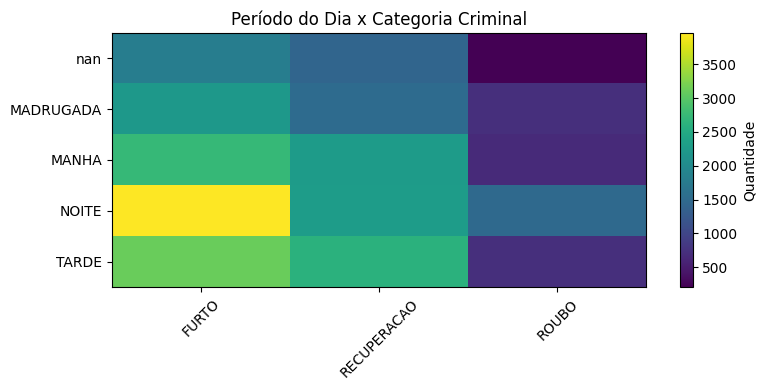

In [10]:
periodo_df = (
    df.filter(
        col("categoria_rubrica").isin(
            "FURTO",
            "ROUBO",
            "RECUPERACAO"
        )
    )
    .groupBy(
        "periodo_dia",
        "categoria_rubrica"
    )
    .count()
    .toPandas()
)

pivot_df = periodo_df.pivot(
    index="periodo_dia",
    columns="categoria_rubrica",
    values="count"
).fillna(0)

plt.figure(figsize=(8, 4))

plt.imshow(pivot_df, aspect="auto")

plt.colorbar(label="Quantidade")

plt.xticks(
    range(len(pivot_df.columns)),
    pivot_df.columns,
    rotation=45
)

plt.yticks(
    range(len(pivot_df.index)),
    pivot_df.index
)

plt.title("Período do Dia x Categoria Criminal")

plt.tight_layout()

plt.show()

#### Bairro x Categoria Criminal

A análise espacial por bairro demonstrou forte concentração das ocorrências na região central da capital paulista, especialmente para registros de:

- furto
- recuperação de veículos
- roubo

O bairro Centro apresentou volume significativamente superior aos demais bairros analisados, indicando possível influência de fatores como:

- alta circulação de pessoas e veículos
- densidade urbana
- concentração comercial
- maior atuação policial e operacional

Além disso, observou-se que os roubos aparentam possuir maior concentração espacial em comparação aos furtos.

## Resumo da Análise Exploratória de Dados (EDA)

A etapa inicial de análise exploratória teve como objetivo validar a consistência dos dados, compreender a distribuição das ocorrências e identificar possíveis padrões temporais, espaciais e categóricos relacionados à criminalidade veicular no estado de São Paulo.

Durante a EDA foram realizadas:

- análises de valores nulos
- identificação e remoção de registros duplicados
- validação de tipos de dados
- criação de categorias analíticas
- criação de variáveis temporais
- validação geoespacial das coordenadas
- análises descritivas e cruzamentos categóricos

Os resultados indicaram que o dataset possui boa viabilidade analítica após os tratamentos realizados, permitindo futuras análises estatísticas e geoespaciais em escala histórica.